# M82 starbust galaxy visualization.
**Author:** Alan Palma

In [1]:
import yt
import matplotlib.pyplot as plt
import numpy as np
from amr_averagers import CustomFinestGrid

In [ ]:
pathM82 = "/home/alanp/Documents/m82_project/output/M82Wind2D_test00/M82Wind_2D_hdf5_plt_cnt_????"

ytM82 = yt.load(pathM82)

yt : [WARNING  ] 2026-06-22 01:26:45,031 Identical domain left edge and right edges along dummy dimension (2), attempting to read anyway
yt : [INFO     ] 2026-06-22 01:26:45,132 Parameters: current_time              = 0.0
yt : [INFO     ] 2026-06-22 01:26:45,133 Parameters: domain_dimensions         = [256 256   1]
yt : [INFO     ] 2026-06-22 01:26:45,134 Parameters: domain_left_edge          = [-3.086e+21 -3.086e+21  0.000e+00]
yt : [INFO     ] 2026-06-22 01:26:45,135 Parameters: domain_right_edge         = [3.086e+21 3.086e+21 1.000e+00]
yt : [INFO     ] 2026-06-22 01:26:45,136 Parameters: cosmological_simulation   = 0


In [21]:
# Get the max and min vlaues
ad = ytM82[0].all_data()[("flash", "dens")]
max_val = np.max(ad).to("g/cm**3")
min_val = np.min(ad).to("g/cm**3")

yt : [WARNING  ] 2026-06-22 01:54:28,742 Identical domain left edge and right edges along dummy dimension (2), attempting to read anyway
yt : [INFO     ] 2026-06-22 01:54:28,826 Parameters: current_time              = 0.0
yt : [INFO     ] 2026-06-22 01:54:28,827 Parameters: domain_dimensions         = [256 256   1]
yt : [INFO     ] 2026-06-22 01:54:28,829 Parameters: domain_left_edge          = [-3.086e+21 -3.086e+21  0.000e+00]
yt : [INFO     ] 2026-06-22 01:54:28,830 Parameters: domain_right_edge         = [3.086e+21 3.086e+21 1.000e+00]
yt : [INFO     ] 2026-06-22 01:54:28,832 Parameters: cosmological_simulation   = 0


yt : [WARNING  ] 2026-06-22 01:39:42,380 Identical domain left edge and right edges along dummy dimension (2), attempting to read anyway


yt : [INFO     ] 2026-06-22 01:39:42,473 Parameters: current_time              = 3165299785471.432
yt : [INFO     ] 2026-06-22 01:39:42,474 Parameters: domain_dimensions         = [256 256   1]
yt : [INFO     ] 2026-06-22 01:39:42,476 Parameters: domain_left_edge          = [-3.086e+21 -3.086e+21  0.000e+00]
yt : [INFO     ] 2026-06-22 01:39:42,478 Parameters: domain_right_edge         = [3.086e+21 3.086e+21 1.000e+00]
yt : [INFO     ] 2026-06-22 01:39:42,479 Parameters: cosmological_simulation   = 0
yt : [WARNING  ] 2026-06-22 01:39:42,499 Identical domain left edge and right edges along dummy dimension (2), attempting to read anyway
yt : [INFO     ] 2026-06-22 01:39:42,567 Parameters: current_time              = 3165299785471.432
yt : [INFO     ] 2026-06-22 01:39:42,568 Parameters: domain_dimensions         = [256 256   1]
yt : [INFO     ] 2026-06-22 01:39:42,569 Parameters: domain_left_edge          = [-3.086e+21 -3.086e+21  0.000e+00]
yt : [INFO     ] 2026-06-22 01:39:42,571 Parame


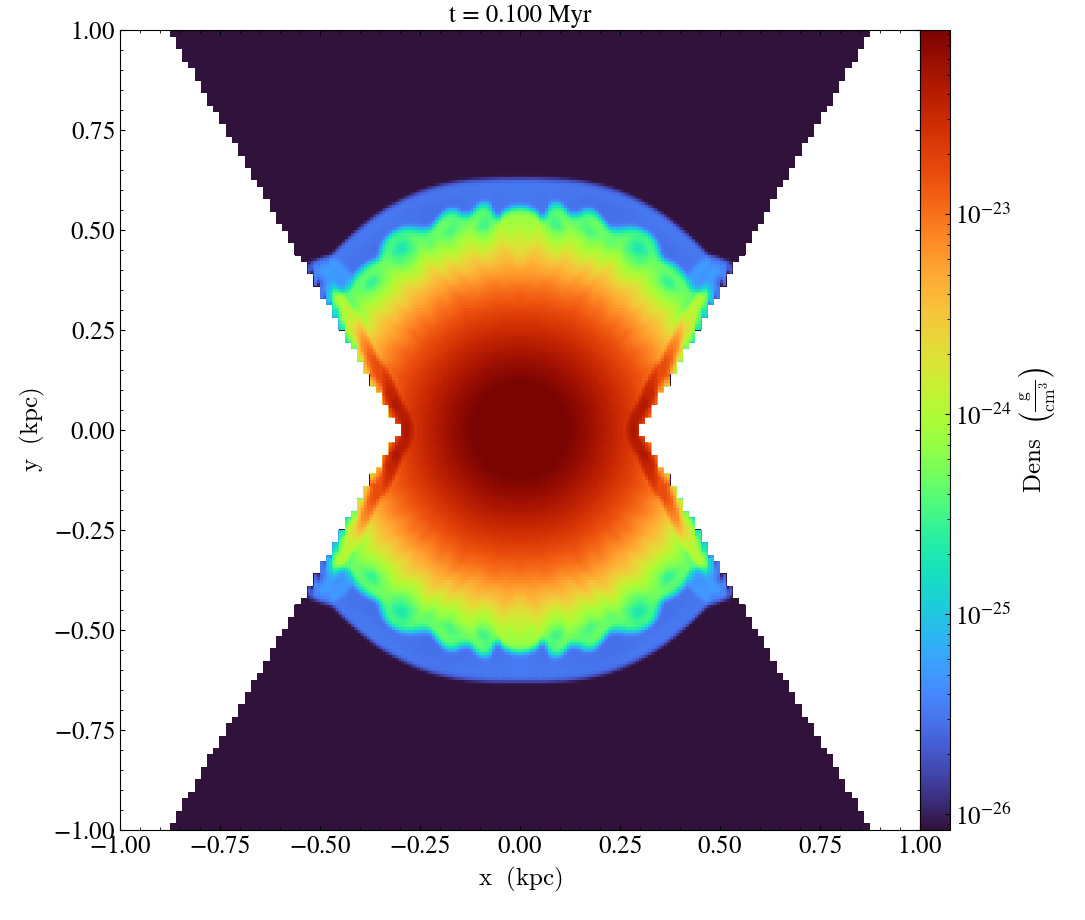

In [19]:
# extract the time from the dataset
time = ytM82[10].current_time.to("Myr")

p_slice_r = yt.SlicePlot(ytM82[10], "z", ("flash", "dens"))
p_slice_r.set_cmap(("flash", "dens"), "turbo")
p_slice_r.set_unit(("flash", "dens"), "g/cm**3")

# Convert limits to CGS (if they are YTArrays in code units)
min_val_cgs = min_val.to("g/cm**3")
max_val_cgs = max_val.to("g/cm**3")

p_slice_r.set_zlim(("flash", "dens"), min_val_cgs, max_val_cgs)
p_slice_r.annotate_title("t = {:.3f} Myr".format(time.value))

p_slice_r.save("my_density_slice.png")

p_slice_r.show()